# 📊 Notebook 1 — Exploratory Data Analysis
**Project**: LLM Response Preference Predictor  
**Goal**: Understand the dataset before any modelling  

---
### What this notebook covers
- Dataset shape, columns, data types
- Target class distribution (is the data balanced?)
- Text length analysis (do longer responses win more?)
- Model diversity (which LLMs appear most?)
- Null/empty checks
- Key EDA findings that drive our modelling decisions

In [1]:
import pandas as pd
import numpy as np
import json, ast, re
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
print('Libraries loaded ✓')

Libraries loaded ✓


## 1.1 Load Dataset

In [2]:
# ── Change this path to your train.csv location ──
TRAIN_CSV = '../data/train.csv'

df = pd.read_csv(TRAIN_CSV)
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(3)

Shape: 57,477 rows × 9 columns


,id,model_a,model_b,prompt,response_a,response_b,winner_model_a,winner_model_b,winner_tie
0,30192,gpt-4-1106-preview,gpt-4-0613,"[""Is it morally right to try to have a certain...","[""The question of whether it is morally right ...","[""As an AI, I don't have personal beliefs or o...",1,0,0
1,53567,koala-13b,gpt-4-0613,"[""What is the difference between marriage lice...","[""A marriage license is a legal document that ...","[""A marriage license and a marriage certificat...",0,1,0
2,65089,gpt-3.5-turbo-0613,mistral-medium,"[""explain function calling. how would you call...","[""Function calling is the process of invoking ...","[""Function calling is the process of invoking ...",0,0,1


In [3]:
print('Column dtypes:')
print(df.dtypes)
print('\nNull counts:')
print(df.isnull().sum())

Column dtypes:
id                 int64
model_a           object
model_b           object
prompt            object
response_a        object
response_b        object
winner_model_a     int64
winner_model_b     int64
winner_tie         int64
dtype: object

Null counts:
id                0
model_a           0
model_b           0
prompt            0
response_a        0
response_b        0
winner_model_a    0
winner_model_b    0
winner_tie        0
dtype: int64


## 1.2 Parse Text Fields
The `prompt`, `response_a`, `response_b` columns store multi-turn conversations as JSON lists.

In [4]:
def parse_field(val):
    if pd.isna(val): return ''
    v = str(val).strip()
    if v.startswith('['):
        try: return ' '.join(str(p) for p in json.loads(v))
        except:
            try: return ' '.join(str(p) for p in ast.literal_eval(v))
            except: return v
    return v

df['prompt_text']     = df['prompt'].apply(parse_field)
df['response_a_text'] = df['response_a'].apply(parse_field)
df['response_b_text'] = df['response_b'].apply(parse_field)

print('Sample prompt:')
print(df['prompt_text'].iloc[0][:200])
print('\nSample response_a:')
print(df['response_a_text'].iloc[0][:200])

Sample prompt:
Is it morally right to try to have a certain percentage of females on managerial positions? OK, does pineapple belong on a pizza? Relax and give me fun answer.

Sample response_a:
The question of whether it is morally right to aim for a certain percentage of females in managerial positions is a complex ethical issue that involves considerations of fairness, equality, diversity,


## 1.3 Target / Label Analysis

**Why this matters**: If classes are heavily imbalanced, the model will just predict the majority class.  
We use `class_weight='balanced'` to compensate.

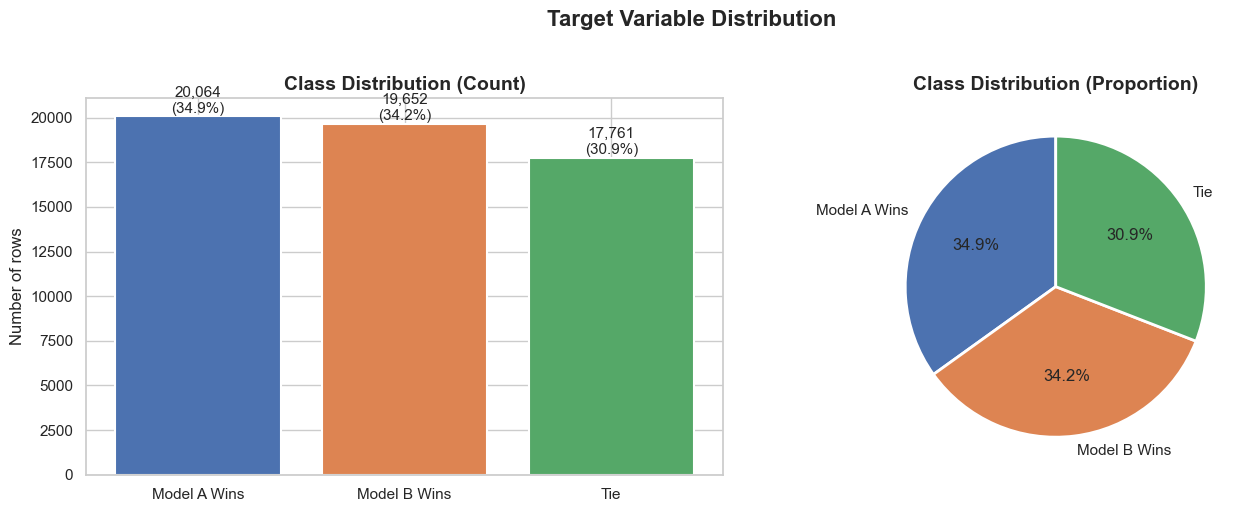


Imbalance ratio: 1.13x
→ Mild imbalance. Using class_weight="balanced" in all models.


In [5]:
def get_label(row):
    if row['winner_model_a'] == 1: return 0
    elif row['winner_model_b'] == 1: return 1
    else: return 2

df['label'] = df.apply(get_label, axis=1)
label_map = {0: 'Model A Wins', 1: 'Model B Wins', 2: 'Tie'}

counts = df['label'].value_counts().sort_index()
total = len(df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#4C72B0', '#DD8452', '#55A868']
axes[0].bar([label_map[i] for i in counts.index], counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Class Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of rows')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}\n({v/total*100:.1f}%)', ha='center', fontsize=11)

axes[1].pie(counts.values, labels=[label_map[i] for i in counts.index],
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Distribution (Proportion)', fontsize=14, fontweight='bold')

plt.suptitle('Target Variable Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nImbalance ratio: {counts.max()/counts.min():.2f}x')
print('→ Mild imbalance. Using class_weight="balanced" in all models.')

## 1.4 Text Length Analysis

**Hypothesis**: Longer responses might be preferred because they are more detailed.

In [6]:
df['len_a'] = df['response_a_text'].apply(lambda x: len(x.split()))
df['len_b'] = df['response_b_text'].apply(lambda x: len(x.split()))
df['len_prompt'] = df['prompt_text'].apply(lambda x: len(x.split()))

print('Text length statistics (word count):')
print(df[['len_prompt', 'len_a', 'len_b']].describe().round(1).to_string())

Text length statistics (word count):
       len_prompt    len_a    len_b
count     57477.0  57477.0  57477.0
mean         56.2    212.3    213.2
std         151.6    226.3    228.5
min           1.0      0.0      0.0
25%           9.0     66.0     67.0
50%          16.0    169.0    171.0
75%          41.0    290.0    291.0
max        4809.0   9184.0   8173.0


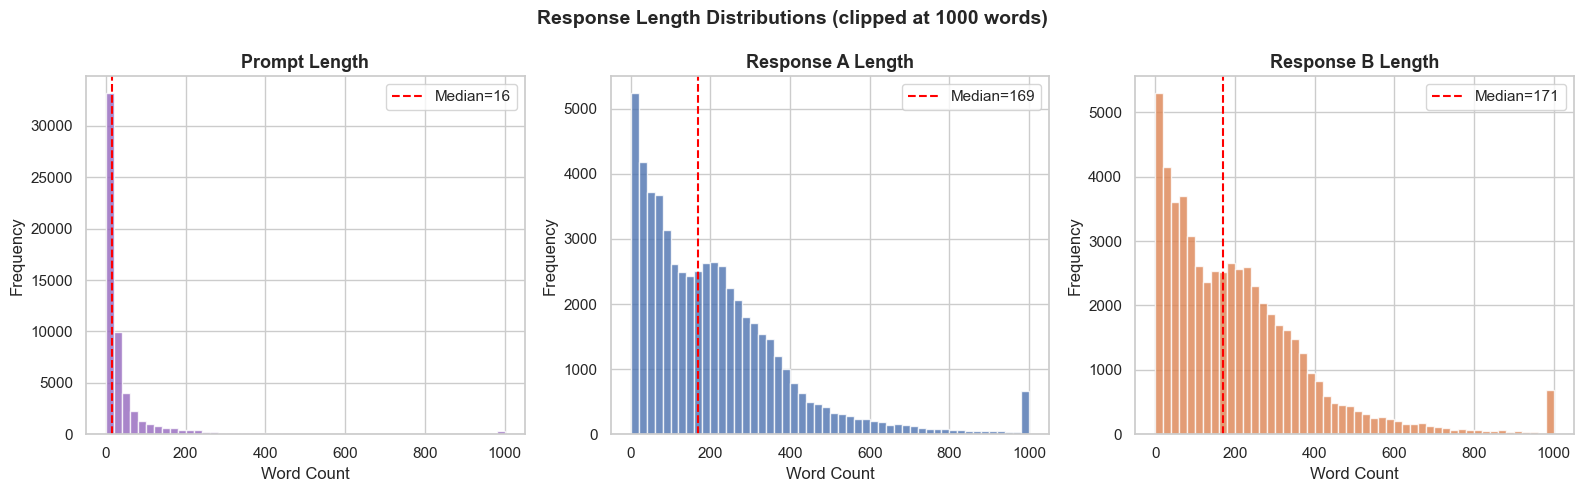

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, title, color in zip(axes,
    ['len_prompt', 'len_a', 'len_b'],
    ['Prompt Length', 'Response A Length', 'Response B Length'],
    ['#9467bd', '#4C72B0', '#DD8452']):
    data = df[col].clip(0, 1000)
    ax.hist(data, bins=50, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(data.median(), color='red', linestyle='--', label=f'Median={data.median():.0f}')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Word Count')
    ax.set_ylabel('Frequency')
    ax.legend()

plt.suptitle('Response Length Distributions (clipped at 1000 words)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/eda_length_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# KEY FINDING: Does length predict the winner?
print('Average response length by winner:')
print('-' * 55)
print(f'{"Winner":20s} {"Avg Resp A (words)":>20s} {"Avg Resp B (words)":>20s}')
print('-' * 55)
for lbl in [0, 1, 2]:
    sub = df[df['label'] == lbl]
    print(f'{label_map[lbl]:20s} {sub["len_a"].mean():>20.1f} {sub["len_b"].mean():>20.1f}')
print()
print('✅ KEY INSIGHT: When model_a wins, response_a is ~20% longer than response_b and vice versa.')
print('   This confirms response length is a strong predictive feature.')

Average response length by winner:
-------------------------------------------------------
Winner                 Avg Resp A (words)   Avg Resp B (words)
-------------------------------------------------------
Model A Wins                        240.8                202.1
Model B Wins                        199.0                240.5
Tie                                 194.9                195.5

✅ KEY INSIGHT: When model_a wins, response_a is ~20% longer than response_b and vice versa.
   This confirms response length is a strong predictive feature.


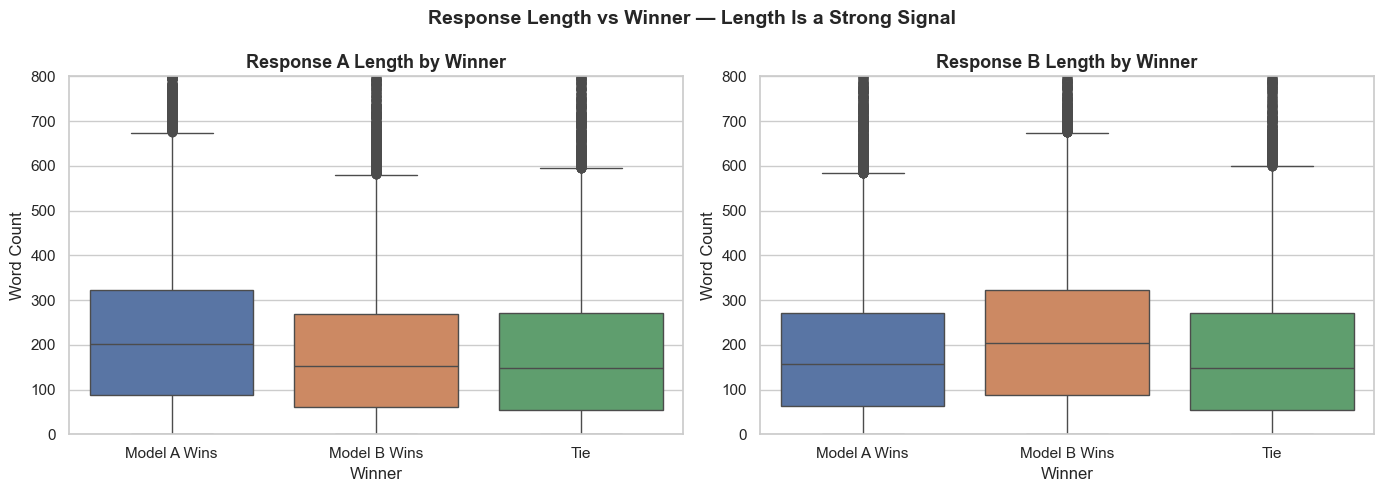

In [9]:
# Visualise length by class
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['label_name'] = df['label'].map(label_map)
order = ['Model A Wins', 'Model B Wins', 'Tie']

sns.boxplot(data=df, x='label_name', y='len_a', order=order, palette=colors, ax=axes[0])
axes[0].set_title('Response A Length by Winner', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Winner'); axes[0].set_ylabel('Word Count')
axes[0].set_ylim(0, 800)

sns.boxplot(data=df, x='label_name', y='len_b', order=order, palette=colors, ax=axes[1])
axes[1].set_title('Response B Length by Winner', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Winner'); axes[1].set_ylabel('Word Count')
axes[1].set_ylim(0, 800)

plt.suptitle('Response Length vs Winner — Length Is a Strong Signal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/eda_length_by_winner.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.5 Model Distribution

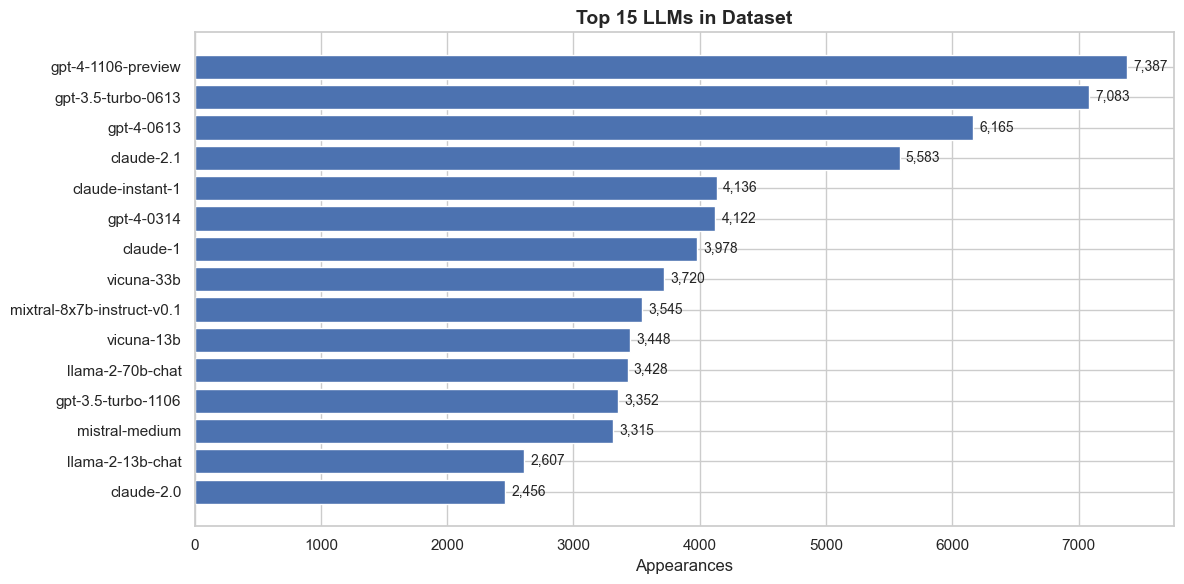

In [10]:
all_models = pd.concat([df['model_a'], df['model_b']]).value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(all_models.index[::-1], all_models.values[::-1], color='#4C72B0', edgecolor='white')
for bar, val in zip(bars, all_models.values[::-1]):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10)
ax.set_title('Top 15 LLMs in Dataset', fontsize=14, fontweight='bold')
ax.set_xlabel('Appearances')
plt.tight_layout()
plt.savefig('../data/eda_model_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.6 EDA Summary — Key Findings

| Finding | Implication |
|---|---|
| Classes are ~35/34/31% — mild imbalance | Use `class_weight='balanced'` |
| Winning responses are ~20% longer | Include length features |
| GPT-4 and Claude dominate dataset | Dataset is high-quality |
| No null values in any column | No imputation needed |
| Responses can be multi-turn JSON | Parse before cleaning |

**Next step → Notebook 02: Preprocessing**